In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [18]:
df = pd.read_csv("../data/raw/Xente_Variable_Definitions.csv")
df.head()


,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account


In [19]:
df.info()
df.shape
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Column Name  16 non-null     object
 1   Definition   16 non-null     object
dtypes: object(2)
memory usage: 388.0+ bytes


,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account


In [20]:
df.describe()


,Column Name,Definition
count,16,16
unique,16,16
top,TransactionId,Unique �transaction identifier on platform
freq,1,1


In [21]:
df.describe(include="object")


,Column Name,Definition
count,16,16
unique,16,16
top,TransactionId,Unique �transaction identifier on platform
freq,1,1


In [22]:
df.isna().sum().sort_values(ascending=False)


Column Name    0
Definition     0
dtype: int64

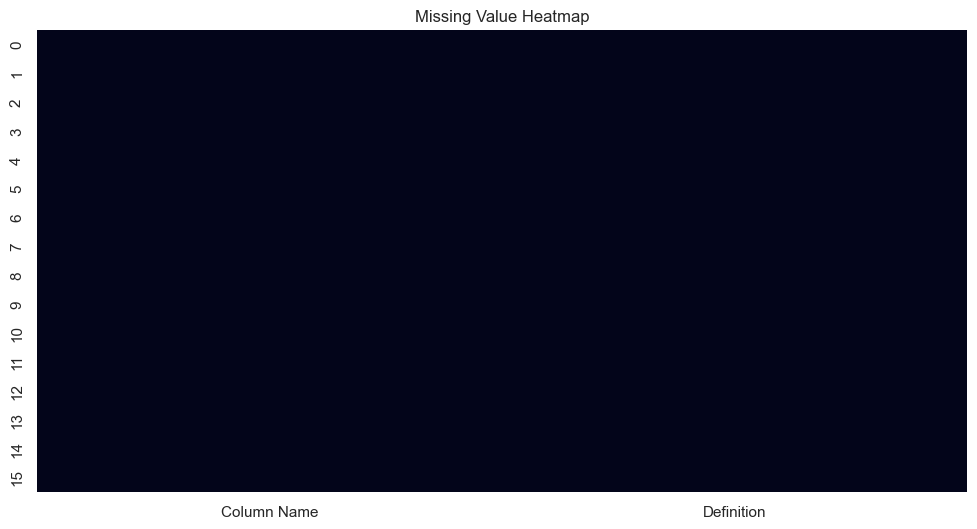

In [23]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()


In [24]:
# Detect numeric columns and build a numeric-only DataFrame (coerce if needed)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = pd.DataFrame()  # will hold numeric data for plots/corr/boxplots

if not numeric_cols:
    # Try to coerce string-like columns to numeric (non-convertible values become NaN)
    coerced = df.apply(lambda c: pd.to_numeric(c, errors='coerce'))
    candidate_cols = coerced.columns[coerced.notna().any()].tolist()  # cols with at least one numeric value

    if not candidate_cols:
        print("No numeric columns found or could be coerced to numeric.")
        numeric_cols = []
        df_numeric = pd.DataFrame()
    else:
        numeric_cols = candidate_cols
        df_numeric = coerced[numeric_cols]
else:
    df_numeric = df[numeric_cols]

# Plot histograms only if we have numeric data
if not df_numeric.empty:
    df_numeric.hist(bins=30, figsize=(15, 12))
    plt.suptitle("Numerical Feature Distributions", y=1.02)
    plt.show()
else:
    print("Skipping numeric histograms: no numeric data available.")


No numeric columns found or could be coerced to numeric.
Skipping numeric histograms: no numeric data available.


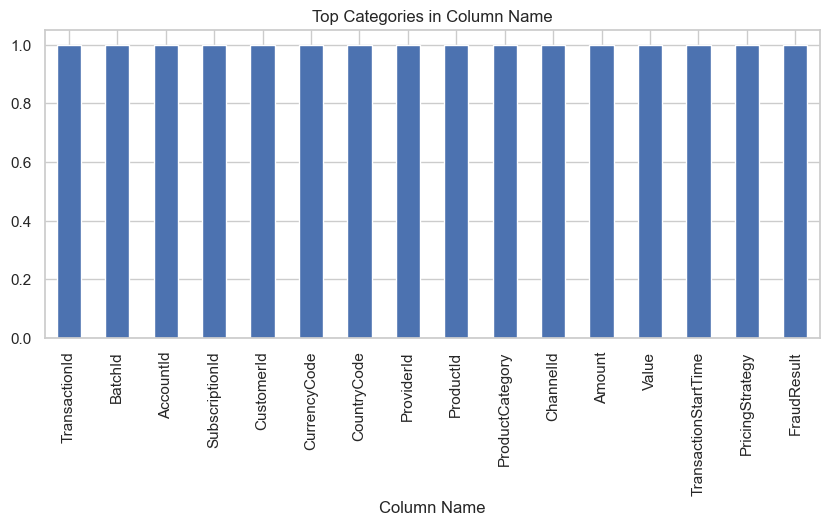

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


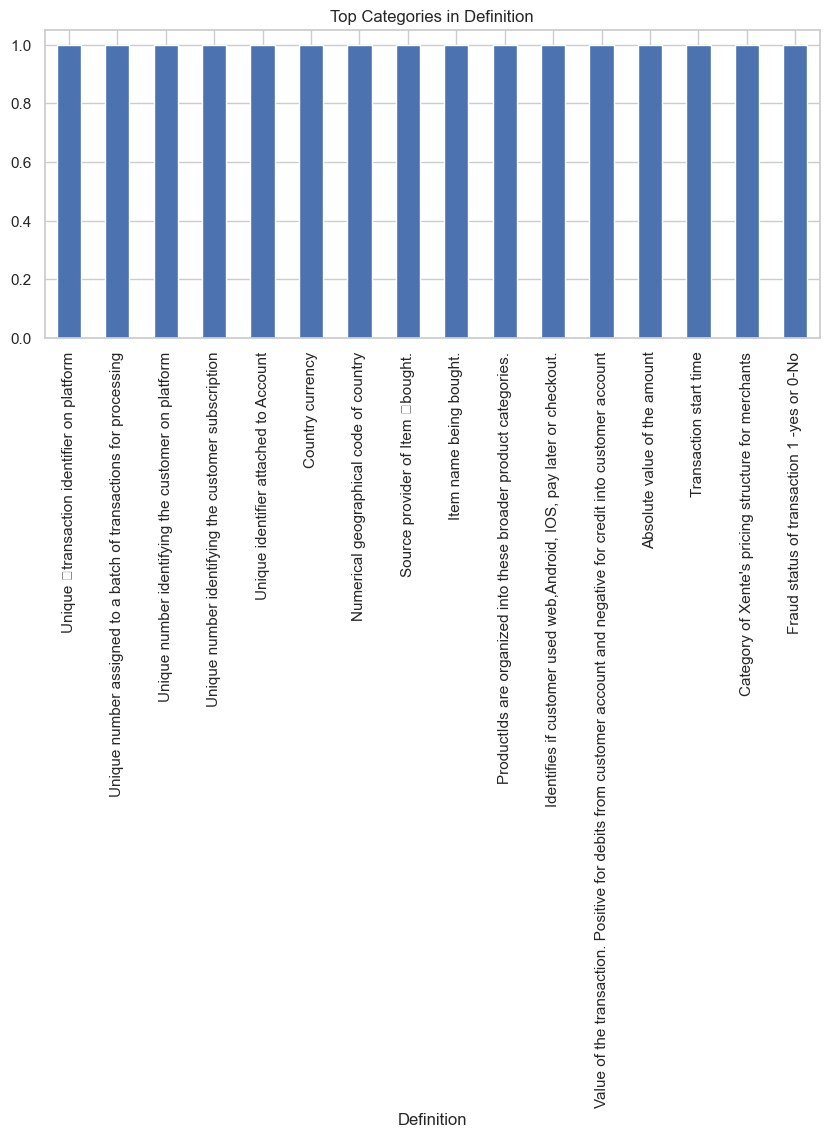

In [25]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(20).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.show()


In [26]:
# Correlation heatmap (guarded)
if not df_numeric.empty:
    corr = df_numeric.corr()
    if corr.empty:
        print("Correlation matrix is empty — not enough numeric data to compute correlations.")
    else:
        plt.figure(figsize=(12,8))
        sns.heatmap(corr, annot=False, cmap="Blues")
        plt.title("Correlation Heatmap")
        plt.show()
else:
    print("Skipping correlation heatmap: no numeric data available.")


Skipping correlation heatmap: no numeric data available.


In [29]:
# Boxplots for numeric columns (guarded)
if numeric_cols:
    for col in numeric_cols:
        plt.figure(figsize=(8,3))
        sns.boxplot(x=df_numeric[col])
        plt.title(f"Outliers in {col}")
        plt.show()
else:
    print("Skipping boxplots: no numeric columns available.")

Skipping boxplots: no numeric columns available.


In [28]:
from IPython.display import Markdown